In [3]:
import sys
import os

# Get the absolute path to the src folder (parent of current file)
notebook_dir = os.path.dirname(os.path.abspath(""))  # current dir is src/glyco
src_path = os.path.abspath(os.path.join(notebook_dir, "."))  # go up to src

# Add src to sys.path
if src_path not in sys.path:
    sys.path.insert(0, src_path)

%load_ext autoreload
%autoreload 2
# Now import the glyco module
import glyco as gl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
d =gl.read_csv(file_path='../../examples/data/out_glucose_sample.csv', delimiter=',')

In [5]:
d_ =gl.read_csv(file_path='../../examples/data/out_glucose_sample.csv', delimiter=',', mask_private_info=True)

In [7]:
d.head()

,Device,Device Timestamp,Record Type,Historic Glucose mmol/L,Scan Glucose mmol/L,Non-numeric Rapid-Acting Insulin,Rapid-Acting Insulin (units),Non-numeric Food,Carbohydrates (grams),Carbohydrates (servings),...,shifted_weekday_number,shifted_weekday_name,shifted_is_weekend,glucose,dg,dt,dg_dt,auc_mean,auc_lim,auc_min
idx,,,,,,,,,,,,,,,,,,,,,
2022-10-16 22:20:00,FreeStyle LibreLink,16-10-2022 22:20,0,5.639970,NaN,NaN,NaN,NaN,NaN,NaN,...,6,Sun,True,6.134984,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-16 22:35:00,FreeStyle LibreLink,16-10-2022 22:35,0,6.425470,NaN,NaN,NaN,NaN,NaN,NaN,...,6,Sun,True,6.134984,0.000000,900.0,0.000000,657.458935,1021.485993,2675.515776
2022-10-16 22:49:00,FreeStyle LibreLink,16-10-2022 22:49,0,6.339514,NaN,NaN,NaN,NaN,NaN,NaN,...,6,Sun,True,6.134984,0.000000,840.0,0.000000,613.628339,953.386927,2497.148058
2022-10-16 23:04:00,FreeStyle LibreLink,16-10-2022 23:04,0,7.102766,NaN,NaN,NaN,NaN,NaN,NaN,...,6,Sun,True,6.622583,0.487599,900.0,0.000542,1096.297765,1460.324824,3114.354607
2022-10-16 23:20:00,FreeStyle LibreLink,16-10-2022 23:20,0,6.381419,NaN,NaN,NaN,NaN,NaN,NaN,...,6,Sun,True,6.607900,-0.014684,960.0,-0.000015,1155.288028,1543.583558,3307.881993


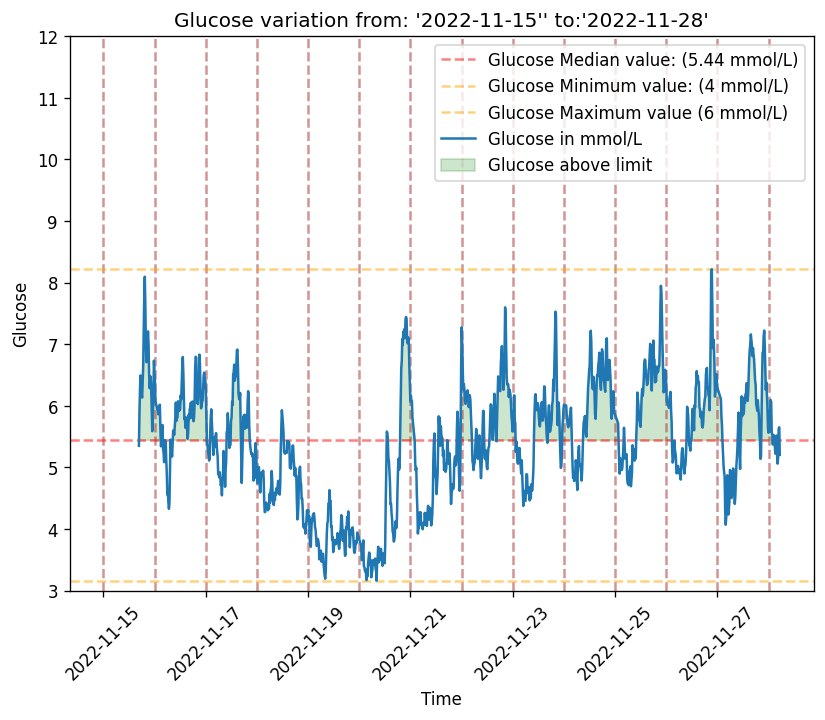

/Users/a961747/restingit/datamesh/selfgit/glyco/src/glyco/utils.py:109: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


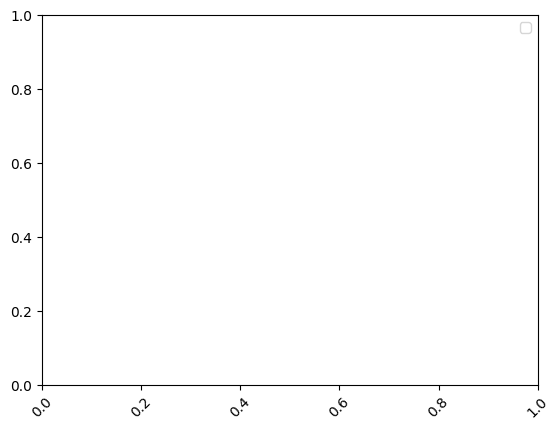

In [9]:
# gl.init_plot()
gl.plot_glucose(d, from_time='2022-11-01')
# gl.end_plot()

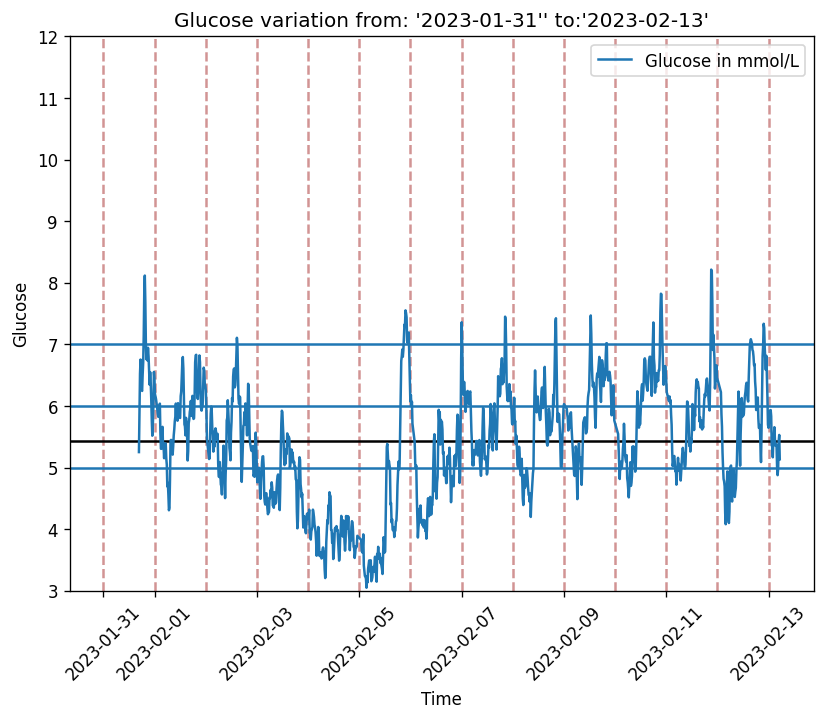

In [10]:
gl.init_plot()
gl.plot_glucose(d_, from_time='2023-01-31')
gl.end_plot()

In [11]:
m_ = gl.auto_recognise_meals(d_)
m = gl.auto_recognise_meals(d)

In [12]:
m.session_id.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39])

In [13]:
m_.session_id.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34])

In [14]:
d_['Notes'].unique()

array(['9b2d5b4678781e53038e91ea5324530a03f27dc1d0e5f6c9bc9d493a23be9de0'],
      dtype=object)

In [15]:
d_['Notes'] = d_['Notes'].astype(str)

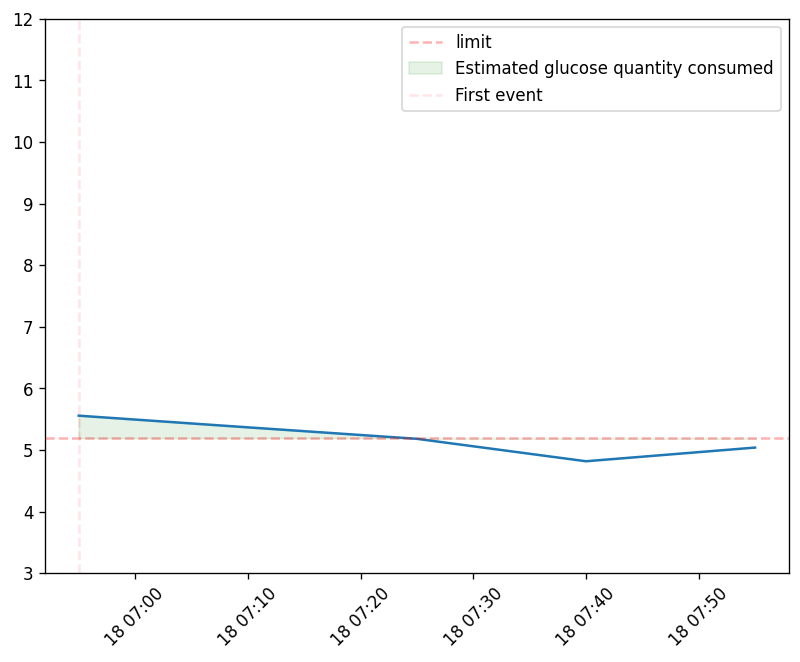

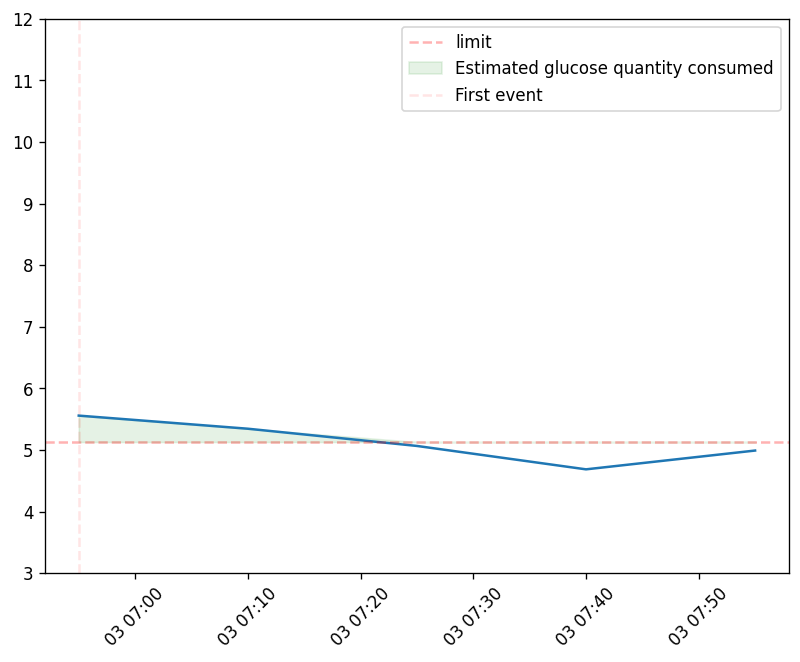

In [16]:
gl.init_plot()
gl.plot_session_response(d, m, session_id=5, use_notes_as_title=False)
gl.end_plot()
gl.init_plot()
gl.plot_session_response(d_, m_, session_id=5, use_notes_as_title=False)
gl.end_plot()

In [17]:
m_[m_['session_id']==5]

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
itsp,,,,,,,,,,,,
2023-01-03 06:55:00,5.55668,2023-01-03 06:55:00,13500.0,2455140.0,True,True,2023-01-03 06:55:00,2023-01-03 06:55:00,5,2023-01-03 06:55:00,2023-01-03 07:55:00,3600.0


In [18]:
d[['glucose', 'tsp']].head()

,glucose,tsp
idx,,
2022-10-16 22:20:00,6.134984,2022-10-16 22:20:00
2022-10-16 22:35:00,6.134984,2022-10-16 22:35:00
2022-10-16 22:49:00,6.134984,2022-10-16 22:49:00
2022-10-16 23:04:00,6.622583,2022-10-16 23:04:00
2022-10-16 23:20:00,6.607900,2022-10-16 23:20:00


In [19]:
d_[['glucose', 'tsp']].head()

,glucose,tsp
idx,,
2023-01-01 22:20:00,6.152152,2023-01-01 22:20:00
2023-01-01 22:35:00,6.152152,2023-01-01 22:35:00
2023-01-01 22:49:00,6.152152,2023-01-01 22:49:00
2023-01-01 23:04:00,6.610256,2023-01-01 23:04:00
2023-01-01 23:20:00,6.578107,2023-01-01 23:20:00


In [20]:
gl.read_df(d[['glucose', 'tsp']], glucose_col='glucose', timestamp_col='tsp')

,glucose,tsp,date,date_str,hour,weekday_number,weekday_name,is_weekend,shifted_tsp,shifted_date,...,shifted_hour,shifted_weekday_number,shifted_weekday_name,shifted_is_weekend,dg,dt,dg_dt,auc_mean,auc_lim,auc_min
idx,,,,,,,,,,,,,,,,,,,,,
2022-10-16 22:20:00,6.134984,2022-10-16 22:20:00,2022-10-16,2022-10-16,22,6,Sun,True,2022-10-16 15:20:00,2022-10-16,...,15,6,Sun,True,NaN,NaN,NaN,NaN,NaN,NaN
2022-10-16 22:35:00,6.134984,2022-10-16 22:35:00,2022-10-16,2022-10-16,22,6,Sun,True,2022-10-16 15:35:00,2022-10-16,...,15,6,Sun,True,0.000000,900.0,0.000000,656.917558,121.485993,2599.191491
2022-10-16 22:49:00,6.134984,2022-10-16 22:49:00,2022-10-16,2022-10-16,22,6,Sun,True,2022-10-16 15:49:00,2022-10-16,...,15,6,Sun,True,0.000000,840.0,0.000000,613.123054,113.386927,2425.912058
2022-10-16 23:04:00,6.297517,2022-10-16 23:04:00,2022-10-16,2022-10-16,23,6,Sun,True,2022-10-16 16:04:00,2022-10-16,...,16,6,Sun,True,0.162533,900.0,0.000181,803.197168,267.765604,2745.471101
2022-10-16 23:20:00,6.455156,2022-10-16 23:20:00,2022-10-16,2022-10-16,23,6,Sun,True,2022-10-16 16:20:00,2022-10-16,...,16,6,Sun,True,0.157638,960.0,0.000164,1008.076479,436.949477,3079.835340
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-28 04:13:00,5.277382,2022-11-28 04:13:00,2022-11-28,2022-11-28,4,0,Mon,False,2022-11-27 21:13:00,2022-11-27,...,21,6,Sun,True,-0.115345,900.0,-0.000128,0.000000,0.000000,1827.349316
2022-11-28 04:29:00,5.164174,2022-11-28 04:29:00,2022-11-28,2022-11-28,4,0,Mon,False,2022-11-27 21:29:00,2022-11-27,...,21,6,Sun,True,-0.113208,960.0,-0.000118,0.000000,0.000000,1840.492759
2022-11-28 04:44:00,5.289671,2022-11-28 04:44:00,2022-11-28,2022-11-28,4,0,Mon,False,2022-11-27 21:44:00,2022-11-27,...,21,6,Sun,True,0.125497,900.0,0.000139,0.000000,0.000000,1838.409235


In [21]:
d.columns

Index(['Device', 'Device Timestamp', 'Record Type', 'Historic Glucose mmol/L',
       'Scan Glucose mmol/L', 'Non-numeric Rapid-Acting Insulin',
       'Rapid-Acting Insulin (units)', 'Non-numeric Food',
       'Carbohydrates (grams)', 'Carbohydrates (servings)',
       'Non-numeric Long-Acting Insulin', 'Long-Acting Insulin Value (units)',
       'Notes', 'Strip Glucose mmol/L', 'Ketone mmol/L',
       'Meal Insulin (units)', 'Correction Insulin (units)',
       'User Change Insulin (units)', 'Serial Number', 'tsp', 'date',
       'date_str', 'hour', 'weekday_number', 'weekday_name', 'is_weekend',
       'shifted_tsp', 'shifted_date', 'shifted_date_str', 'shifted_hour',
       'shifted_weekday_number', 'shifted_weekday_name', 'shifted_is_weekend',
       'glucose', 'dg', 'dt', 'dg_dt', 'auc_mean', 'auc_lim', 'auc_min'],
      dtype='object')

In [22]:
gl.get_stats(d, stats_cols=['glucose', 'auc_mean'], percentiles=[.75, .8, .9, .99])

,glucose,auc_mean
count,1300.000000,1299.000000
mean,5.404475,363.751654
std,0.955238,526.180232
min,3.162189,0.000000
50%,5.433483,25.821259
75%,6.084305,620.206538
80%,6.233691,756.004560
90%,6.597362,1090.469006
99%,7.469522,1981.856725
max,8.217115,5986.123514


In [23]:
%reload_ext autoreload

In [24]:
m_.columns

Index(['glucose', 'tsp', 'dt_next_event', 'dt_prev_event', 'is_session_first',
       'is_session_last', 'session_first', 'session_last', 'session_id',
       'estimated_start', 'estimated_end', 'estimated_len'],
      dtype='object')

In [25]:
gl.describe_glucose(d)

Glucose Data Summary

• Total number of days in the data: 43
• Starting at: 2022-10-16 22:20
• Ending at: 2022-11-28 05:14

     Glucose Statistics      
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Measure ┃ Value in mmol/L ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Mean    │ 5.40            │
│ Std     │ 0.96            │
│ Min     │ 3.16            │
│ 25%     │ 4.79            │
│ 50%     │ 5.43            │
│ 75%     │ 6.08            │
│ Max     │ 8.22            │
└─────────┴─────────────────┘

Columns in the data: Device, Device Timestamp, Record Type, Historic Glucose mmol/L, Scan Glucose mmol/L, 
Non-numeric Rapid-Acting Insulin, Rapid-Acting Insulin (units), Non-numeric Food, Carbohydrates (grams), 
Carbohydrates (servings), Non-numeric Long-Acting Insulin, Long-Acting Insulin Value (units), Notes, Strip Glucose 
mmol/L, Ketone mmol/L, Meal Insulin (units), Correction Insulin (units), User Change Insulin (units), Serial 
Number, tsp, date, date_str, hour, weekday_number, weekday_name, is_weekend, shifted_tsp, shifted_date, 
shifted_date_str, shifted_hour, shifted_weekday_number, shifted_weekday_name, shifted_is_weekend, glucose, dg, dt, 
dg_dt, auc_mean, auc_lim, auc_min

First rows in the data:
                                     tsp   glucose
idx                                              
2022-10-16 22:20:00 2022-10-16 22:20:00  6.134984
2022-10-16 22:35:00 2022-10-16 22:35:00  6.134984
2022-10-16 22:49:00 2022-10-16 22:49:00  6.134984
2022-10-16 23:04:00 2022-10-16 23:04:00  6.622583
2022-10-16 23:20:00 2022-10-16 23:20:00  6.607900

In [26]:
m_

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
itsp,,,,,,,,,,,,
2023-01-01 22:20:00,6.152152,2023-01-01 22:20:00,NaN,900.0,True,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:35:00,6.152152,2023-01-01 22:35:00,900.0,840.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:49:00,6.152152,2023-01-01 22:49:00,840.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:04:00,6.610256,2023-01-01 23:04:00,900.0,960.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:20:00,6.578107,2023-01-01 23:20:00,960.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-13 02:28:00,5.516410,2023-02-13 02:28:00,900.0,900.0,False,False,2023-02-12 09:23:00,2023-02-13 02:58:00,33,2023-02-12 09:23:00,2023-02-13 03:58:00,66900.0
2023-02-13 02:43:00,5.654388,2023-02-13 02:43:00,900.0,900.0,False,False,2023-02-12 09:23:00,2023-02-13 02:58:00,33,2023-02-12 09:23:00,2023-02-13 03:58:00,66900.0
2023-02-13 02:58:00,5.450830,2023-02-13 02:58:00,900.0,6360.0,False,True,2023-02-12 09:23:00,2023-02-13 02:58:00,33,2023-02-12 09:23:00,2023-02-13 03:58:00,66900.0


In [27]:
m_

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
itsp,,,,,,,,,,,,
2023-01-01 22:20:00,6.152152,2023-01-01 22:20:00,NaN,900.0,True,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:35:00,6.152152,2023-01-01 22:35:00,900.0,840.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 22:49:00,6.152152,2023-01-01 22:49:00,840.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:04:00,6.610256,2023-01-01 23:04:00,900.0,960.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
2023-01-01 23:20:00,6.578107,2023-01-01 23:20:00,960.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 00:20:00,7200.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-13 02:28:00,5.516410,2023-02-13 02:28:00,900.0,900.0,False,False,2023-02-12 09:23:00,2023-02-13 02:58:00,33,2023-02-12 09:23:00,2023-02-13 03:58:00,66900.0
2023-02-13 02:43:00,5.654388,2023-02-13 02:43:00,900.0,900.0,False,False,2023-02-12 09:23:00,2023-02-13 02:58:00,33,2023-02-12 09:23:00,2023-02-13 03:58:00,66900.0
2023-02-13 02:58:00,5.450830,2023-02-13 02:58:00,900.0,6360.0,False,True,2023-02-12 09:23:00,2023-02-13 02:58:00,33,2023-02-12 09:23:00,2023-02-13 03:58:00,66900.0


In [28]:
e_=gl.get_event_sessions(m_, d_)

KeyError: 'Notes'

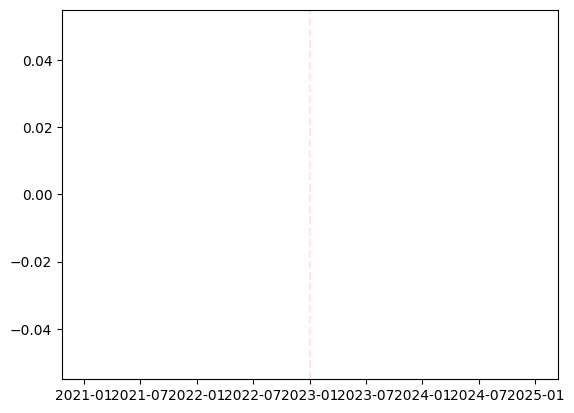

In [29]:
gl.plot_session_response(d, e_, 1, True)

In [30]:
e_.head()

,glucose,tsp,dt_next_event,dt_prev_event,is_session_first,is_session_last,session_first,session_last,session_id,estimated_start,estimated_end,estimated_len
itsp,,,,,,,,,,,,
2023-01-01 22:20:00,6.152152,2023-01-01 22:20:00,NaN,900.0,True,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 22:35:00,6.152152,2023-01-01 22:35:00,900.0,840.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 22:49:00,6.152152,2023-01-01 22:49:00,840.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 23:04:00,6.610256,2023-01-01 23:04:00,900.0,960.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0
2023-01-01 23:20:00,6.578107,2023-01-01 23:20:00,960.0,900.0,False,False,2023-01-01 22:20:00,2023-01-02 00:20:00,1,2023-01-01 22:20:00,2023-01-02 02:21:00,14460.0


In [ ]:
d_.tsp.min()

Timestamp('2023-01-01 22:20:00')

In [ ]:
m_.tsp.min()

Timestamp('2023-01-01 22:20:00')

In [32]:
gl.describe_all_sessions(m_, d_)

Event Sessions Summary

• Total number of sessions: 34
• Session time span: 2023-01-01 22:20 to 2023-02-13 04:59

• Average session length: 344.7 min
• Median session length: 142.5 min

                            Session Glucose Response                             
┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Session ID ┃ Start            ┃ End              ┃ Mean Glucose ┃ Max Glucose ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 1          │ 2023-01-01 22:20 │ 2023-01-02 00:20 │ 6.32         │ 6.61        │
│ 2          │ 2023-01-02 02:21 │ 2023-01-02 02:51 │ 5.88         │ 6.24        │
│ 3          │ 2023-01-02 12:06 │ 2023-01-03 01:23 │ 6.11         │ 7.60        │
│ 4          │ 2023-01-03 03:10 │ 2023-01-03 03:10 │ 5.51         │ 5.51        │
│ 5          │ 2023-01-03 06:55 │ 2023-01-03 06:55 │ 5.56         │ 5.56        │
│ 6          │ 2023-01-31 16:54 │ 2023-02-01 03:44 │ 6.34         │ 8.12        │
│ 7          │ 2023-02-01 07:29 │ 2023-02-02 00:33 │ 5.99         │ 6.83        │
│ 8          │ 2023-02-02 02:05 │ 2023-02-02 05:35 │ 5.59         │ 5.99        │
│ 9          │ 2023-02-02 09:50 │ 2023-02-02 10:50 │ 5.85         │ 6.09        │
│ 10         │ 2023-02-02 11:51 │ 2023-02-02 16:23 │ 6.31         │ 7.11        │
│ 11         │ 2023-02-02 17:38 │ 2023-02-02 20:38 │ 5.85         │ 6.36        │
│ 12         │ 2023-02-02 23:24 │ 2023-02-02 23:24 │ 5.57         │ 5.57        │
│ 13         │ 2023-02-03 11:27 │ 2023-02-03 12:27 │ 5.74         │ 5.92        │
│ 14         │ 2023-02-03 14:13 │ 2023-02-03 15:13 │ 5.48         │ 5.55        │
│ 15         │ 2023-02-05 19:11 │ 2023-02-06 00:57 │ 6.75         │ 7.55        │
│ 16         │ 2023-02-06 02:00 │ 2023-02-06 02:00 │ 5.41         │ 5.41        │
│ 17         │ 2023-02-06 11:00 │ 2023-02-06 11:15 │ 5.48         │ 5.54        │
│ 18         │ 2023-02-06 13:01 │ 2023-02-06 15:01 │ 5.69         │ 5.94        │
│ 19         │ 2023-02-06 21:49 │ 2023-02-07 04:36 │ 6.01         │ 7.36        │
│ 20         │ 2023-02-07 06:51 │ 2023-02-07 08:21 │ 5.37         │ 5.45        │
│ 21         │ 2023-02-07 09:51 │ 2023-02-07 10:36 │ 5.76         │ 5.97        │
│ 22         │ 2023-02-07 13:08 │ 2023-02-08 01:42 │ 6.08         │ 7.45        │
│ 23         │ 2023-02-08 09:58 │ 2023-02-08 22:01 │ 6.04         │ 7.42        │
│ 24         │ 2023-02-08 23:17 │ 2023-02-09 00:02 │ 5.79         │ 6.03        │
│ 25         │ 2023-02-09 01:03 │ 2023-02-09 03:48 │ 5.77         │ 5.97        │
│ 26         │ 2023-02-09 09:04 │ 2023-02-09 23:38 │ 6.32         │ 7.47        │
│ 27         │ 2023-02-10 01:25 │ 2023-02-10 01:25 │ 5.54         │ 5.54        │
│ 28         │ 2023-02-10 03:55 │ 2023-02-10 04:25 │ 5.54         │ 5.71        │
│ 29         │ 2023-02-10 10:11 │ 2023-02-11 00:14 │ 6.51         │ 7.82        │
│ 30         │ 2023-02-11 01:16 │ 2023-02-11 02:31 │ 5.99         │ 6.15        │
│ 31         │ 2023-02-11 09:32 │ 2023-02-11 23:50 │ 6.19         │ 8.21        │
│ 32         │ 2023-02-12 01:38 │ 2023-02-12 02:08 │ 5.92         │ 6.22        │
│ 33         │ 2023-02-12 09:23 │ 2023-02-13 02:58 │ 6.13         │ 7.33        │
│ 34         │ 2023-02-13 04:44 │ 2023-02-13 04:59 │ 5.48         │ 5.53        │
└────────────┴──────────────────┴──────────────────┴──────────────┴─────────────┘

Columns in sessions data: glucose, tsp, dt_next_event, dt_prev_event, is_session_first, is_session_last, 
session_first, session_last, session_id, estimated_start, estimated_end, estimated_len

First rows in the sessions DataFrame:
                       glucose                 tsp  dt_next_event  \
itsp                                                               
2023-01-01 22:20:00  6.152152 2023-01-01 22:20:00            NaN   
2023-01-01 22:35:00  6.152152 2023-01-01 22:35:00          900.0   
2023-01-01 22:49:00  6.152152 2023-01-01 22:49:00          840.0   
2023-01-01 23:04:00  6.610256 2023-01-01 23:04:00          900.0   
2023-01-01 23:20:00  6.578107 2023-01-01 23:20:00          960.0   

                     dt_prev_event  is_session_first  is_session_last  \
itsp                                                                    
2023-01-01 22:20:00          900.0              True            False   
2023-01-01 22:35:00          840.0             False            False   
2023-01-01 22:49:00          900.0             False            False   
2023-01-01 23:04:00          960.0             False            False   
2023-01-01 23:20:00          900.0             False            False   

                          session_first        session_last  session_id  \
itsp                                                                      
2023-01-01 22:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 22:35:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 22:49:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 23:04:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   
2023-01-01 23:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00           1   

                        estimated_start       estimated_end  estimated_len  
itsp                                                                        
2023-01-01 22:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 22:35:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 22:49:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 23:04:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0  
2023-01-01 23:20:00 2023-01-01 22:20:00 2023-01-02 00:20:00         7200.0

In [ ]:
from rich.console import Console
from rich.table import Table

from datetime import timedelta as tdel
from datetime import datetime as dt
import pandas as pd
from matplotlib import pyplot as plt

def describe_meal(gdf: pd.DataFrame, edf: pd.DataFrame, eid: int):
    """Describes a single meal session by providing metadata, duration, 
    and detailed glucose statistics for that specific meal.

    Args:
        gdf (pd.DataFrame): The glucose DataFrame with timestamp index and glucose column.
        edf (pd.DataFrame): The event sessions DataFrame.
        eid (int): The event/session ID to describe.
    """
    console = Console()

    if edf.empty or eid not in edf['session_id'].unique():
        console.print(f"[bold red]Meal session with ID {eid} not found.[/bold red]")
        return

    # Extract the session row
    meal = edf[edf['session_id'] == eid].iloc[0]

    start = pd.to_datetime(meal['session_first'])
    end = pd.to_datetime(meal['session_last'])
    duration_min = (end - start).total_seconds() / 60

    console.print(f"[bold magenta]Meal Session {eid}[/bold magenta]")
    console.print(
        f"• Start: [bold green]{start.strftime('%Y-%m-%d %H:%M')}[/bold green]\n"
        f"• End: [bold green]{end.strftime('%Y-%m-%d %H:%M')}[/bold green]\n"
        f"• Duration: [bold yellow]{duration_min:.1f} min[/bold yellow]"
    )

    # Extract glucose data for this session
    truncated = gdf.loc[start:end, 'glucose']

    if truncated.empty:
        console.print("[bold red]No glucose readings found for this meal session.[/bold red]")
        return

    # Compute stats
    mean_glucose = truncated.mean()
    peak_glucose = truncated.max()
    min_glucose = truncated.min()
    delta_glucose = peak_glucose - min_glucose

    # Compute AUC for this session
    auc_df = gl.get_sessions_auc(edf[edf['session_id'] == eid], gdf)
    auc_val = auc_df.loc[auc_df['session_id'] == eid, "auc_mean"].values[0]

    table = Table(title=f"Glucose Stats for Meal {eid}", show_header=True, header_style="bold magenta")
    table.add_column("Metric")
    table.add_column("Value")

    table.add_row("Mean Glucose", f"{mean_glucose:.2f}")
    table.add_row("Peak Glucose", f"{peak_glucose:.2f}")
    table.add_row("Min Glucose", f"{min_glucose:.2f}")
    table.add_row("Delta (Peak - Min)", f"{delta_glucose:.2f}")
    table.add_row("AUC", f"{auc_val:.2f}")

    console.print(table)

    console.print(
        f"[bold magenta]First glucose rows in session {eid}:[/bold magenta]\n",
        truncated.head()
    )

In [33]:
m_.columns

Index(['glucose', 'tsp', 'dt_next_event', 'dt_prev_event', 'is_session_first',
       'is_session_last', 'session_first', 'session_last', 'session_id',
       'estimated_start', 'estimated_end', 'estimated_len'],
      dtype='object')

In [36]:
gl.describe_session(d_, m_, 2)

Session 2

• Start: 2023-01-02 02:21
• End: 2023-01-02 02:51
• Duration: 30.0 min

 Glucose Stats for Session 2  
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Metric             ┃ Value ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│ Mean Glucose       │ 5.88  │
│ Peak Glucose       │ 6.24  │
│ Min Glucose        │ 5.45  │
│ Delta (Peak - Min) │ 0.78  │
└────────────────────┴───────┘

First glucose rows in session 2:
 idx
2023-01-02 02:21:00    6.236447
2023-01-02 02:36:00    5.962667
2023-01-02 02:51:00    5.454874
Name: glucose, dtype: float64

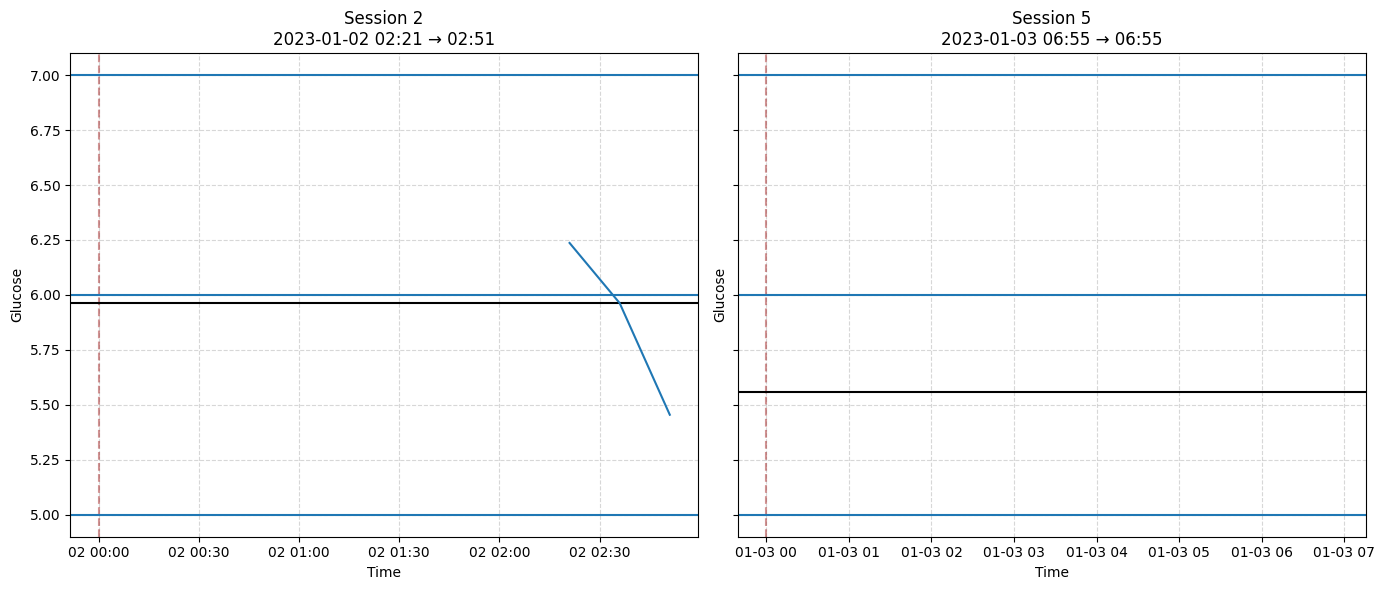

In [47]:
gl.plot_compare_sessions(d_, m_, 2, 5)

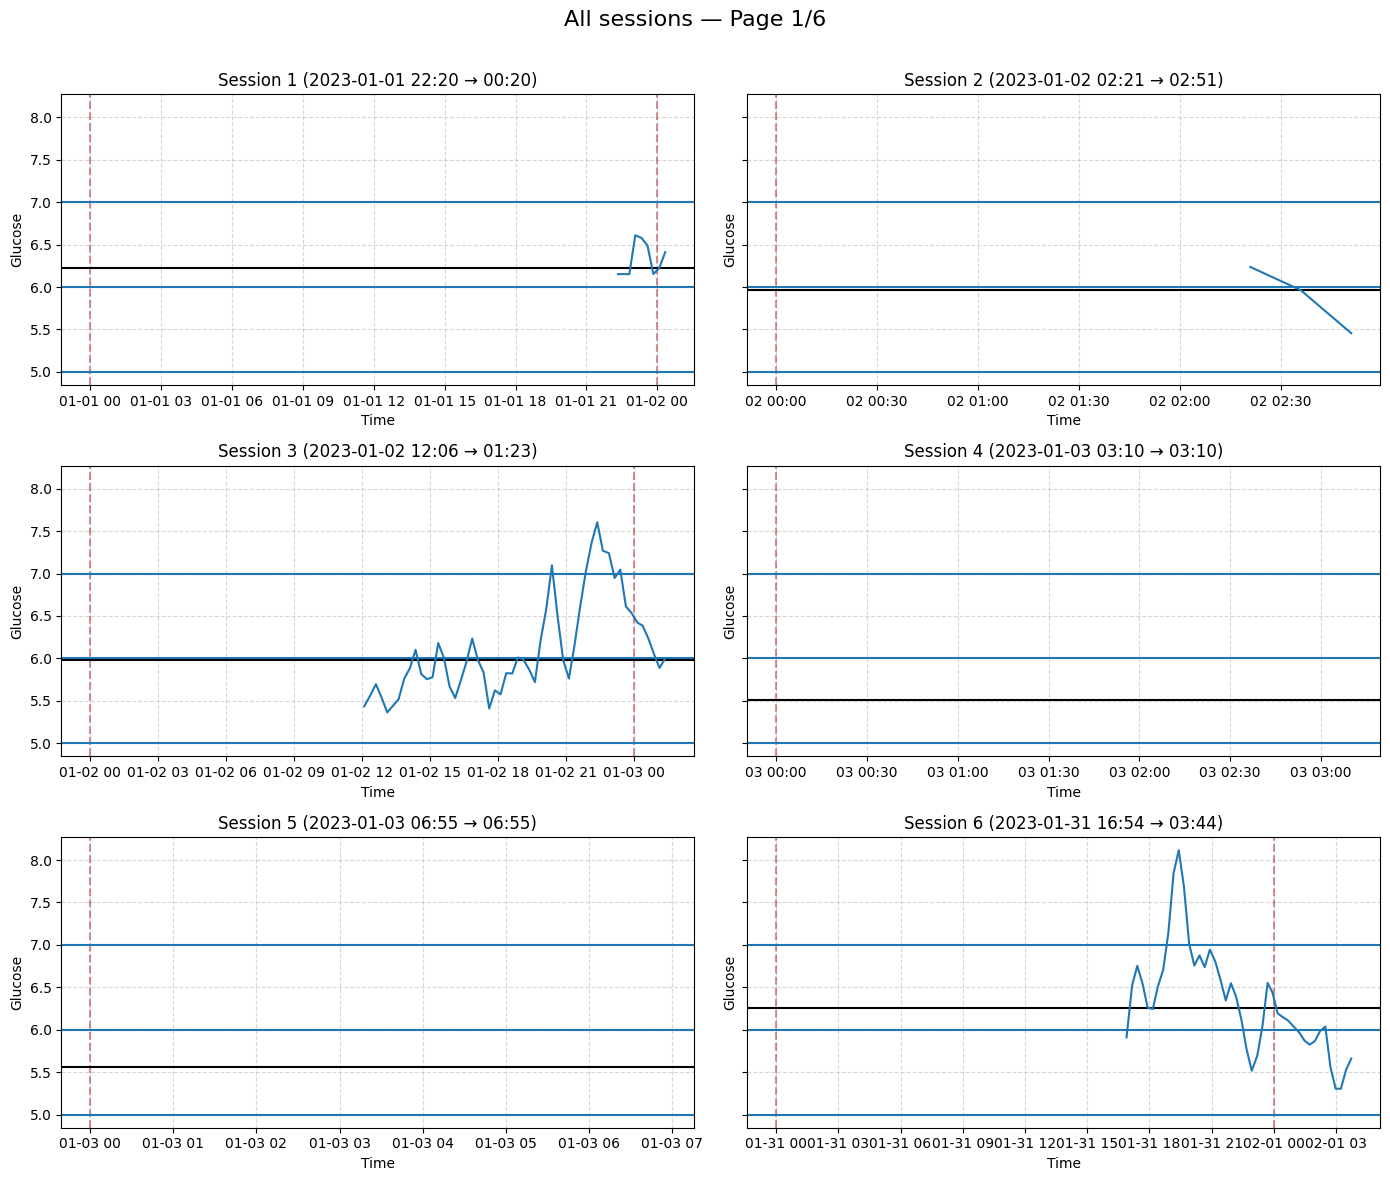

Showing page 1 of 6 (34 sessions total)
To see the next page, call with page=1


In [49]:
gl.plot_all_sessions(d_, m_, page=0)